In [4]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!pip install python-dotenv

In [6]:
from dotenv import load_dotenv
import os
load_dotenv()
print(os.getenv('DB_NAME'))

customer_behavior


In [2]:
df= pd.read_csv("customer_shopping_behavior.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df['Review Rating']= df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

In [8]:
df['Review Rating'].dtype

dtype('float64')

In [9]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [10]:
df.columns=df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [11]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [12]:
# create a column age_group
labels = ['Young Adult','Adult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels = labels)

In [13]:
df['age_group'].dtype

CategoricalDtype(categories=['Young Adult', 'Adult', 'Middle-aged', 'Senior'], ordered=True, categories_dtype=object)

In [14]:
df['age_group']=df['age_group'].astype(str)

In [15]:
df[['age','age_group']].head(10)


,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [16]:
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [17]:
# create column purchase_frequency_days

frequency_mapping = {
    'Fortnightly':14,
    'Weekly':7,
    'Monthly':30,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Annually':365,
    'Every 3 Months':90
}
df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)
df['purchase_frequency_days'].astype(int)

0        14
1        14
2         7
3         7
4       365
       ... 
3895      7
3896     14
3897     90
3898      7
3899     90
Name: purchase_frequency_days, Length: 3900, dtype: int64

In [18]:
df[['frequency_of_purchases','purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [19]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [20]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [21]:
df = df.drop('promo_code_used',axis = 1)

In [116]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [117]:
df.to_csv("Customer_Shopping_Clean_data.csv",index = False)

In [23]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [24]:
# connect to PostgresSQL
username='postgres'
password = '7876'
host = 'localhost'
port = '5432'
database = 'customer_behavior'

# create engine to connect python with postgres
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
table_name = 'customer'
df.to_sql(table_name, engine, if_exists='replace', index=False)
print(f"Data successfully loaded into the table '{table_name}' in database '{database}'")

Data successfully loaded into the table 'customer' in database 'customer_behavior'


In [25]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [26]:
### Q1. What is the total revenue generated by male vs female

df_gender_revenue=pd.read_sql("""
SELECT gender,SUM(purchase_amount) as total_revenue
FROM customer
GROUP BY gender
ORDER BY total_revenue DESC;
""",engine)
print(df_gender_revenue)


   gender  total_revenue
0    Male       157890.0
1  Female        75191.0


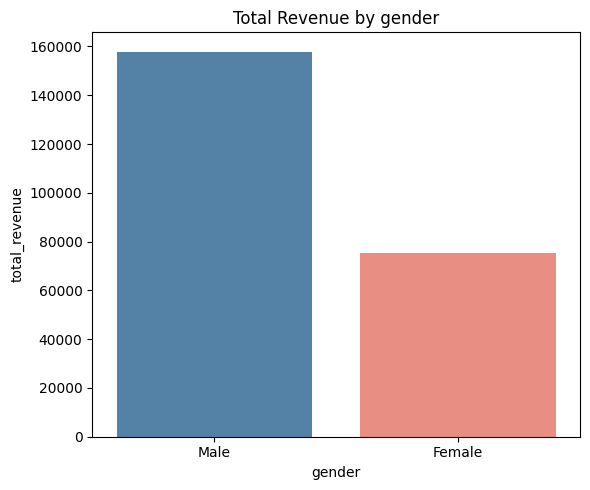

In [27]:
plt.figure(figsize=(6,5))
sns.barplot(x = 'gender',y='total_revenue',data=df_gender_revenue,hue='gender',palette=['steelblue','salmon'],legend=False)
plt.title("Total Revenue by gender")
plt.tight_layout()
plt.show()


In [28]:
### Q2. Which customers used a discount but still spent more thatn the average purchase amount?
df_customer_purchase_discount = pd.read_sql(""" 
SELECT customer_id,purchase_amount
FROM customer
WHERE discount_applied = 'Yes' and purchase_amount >= (SELECT AVG(purchase_amount) from customer)
""",engine)
print(df_customer_purchase_discount)


     customer_id  purchase_amount
0              2               64
1              3               73
2              4               90
3              7               85
4              9               97
..           ...              ...
834         1667               64
835         1671               73
836         1673               73
837         1674               62
838         1676               90

[839 rows x 2 columns]


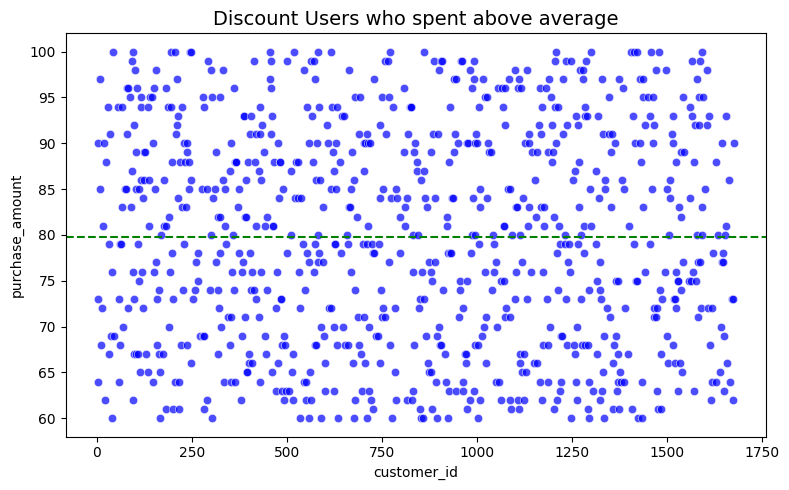

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'customer_id',y='purchase_amount',data = df_customer_purchase_discount,alpha = 0.7,color='blue')

avg = df_customer_purchase_discount['purchase_amount'].mean()
plt.axhline(y=avg,color='green',linestyle='--',label= f'Avg:${avg:2f}')
plt.title("Discount Users who spent above average",fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# Q3. Which are the top 5 products with the highest average review rating?
df_top5_average_review = pd.read_sql("""
SELECT item_purchased,AVG(review_rating) as average_review
FROM customer
GROUP BY item_purchased
ORDER BY average_review DESC
limit 5;

""",engine)
print(df_top5_average_review)


  item_purchased  average_review
0         Gloves        3.861429
1        Sandals        3.844375
2          Boots        3.818750
3            Hat        3.801299
4          Skirt        3.784810


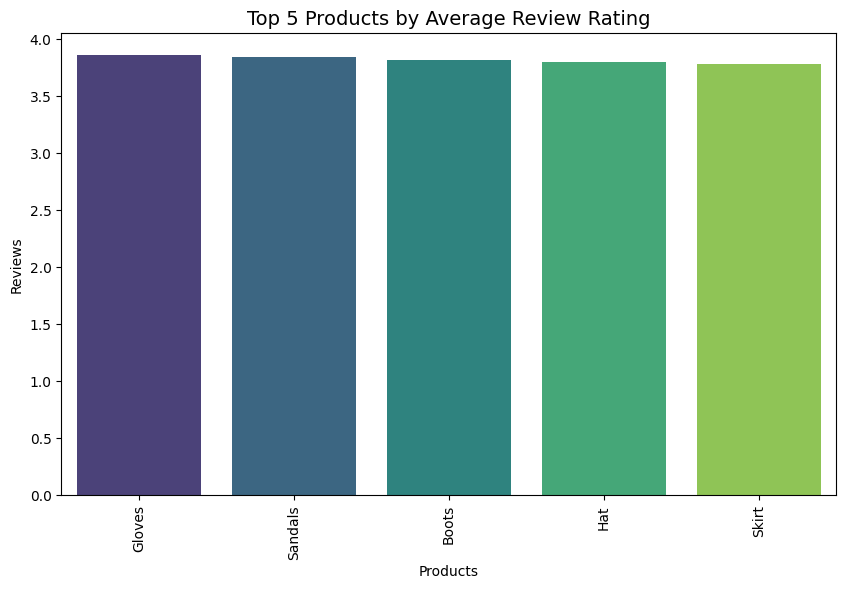

In [114]:
plt.figure(figsize=(10,6))
sns.barplot(x='item_purchased',y='average_review',data = df_top5_average_review,hue='item_purchased',palette='viridis')
plt.xticks(rotation = 90)
plt.title("Top 5 Products by Average Review Rating", fontsize=14)
plt.xlabel("Products")
plt.ylabel('Reviews')
plt.show()

In [32]:
### Q4. Compare the average Purchase amounts b/w standard and express shipping
df_average_shipping = pd.read_sql("""
SELECT shipping_type,AVG(purchase_amount) as avg_purchase_amt
FROM customer
WHERE shipping_type in ('Standard' , 'Express')
GROUP BY shipping_type
ORDER BY avg_purchase_amt DESC
""",engine)
print(df_average_shipping)

  shipping_type  avg_purchase_amt
0       Express         60.475232
1      Standard         58.460245


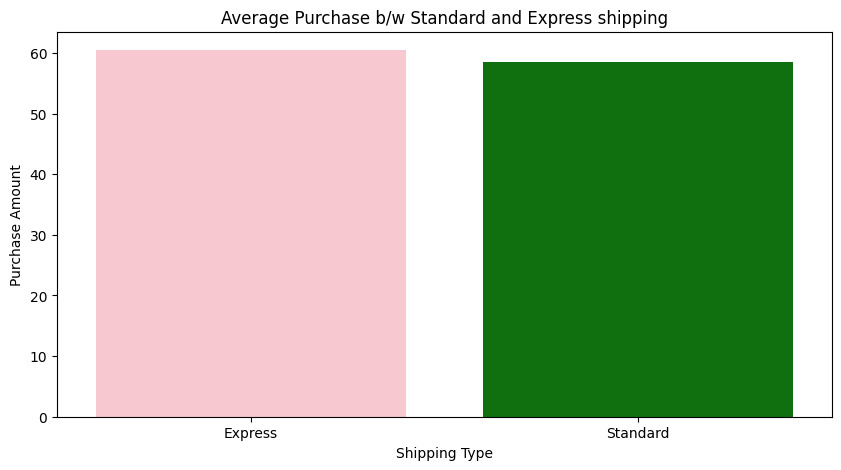

In [115]:
plt.figure(figsize=(10,5))
sns.barplot(x = 'shipping_type',y='avg_purchase_amt',data = df_average_shipping,hue='shipping_type',palette=['pink','green'])
plt.title("Average Purchase b/w Standard and Express shipping")
plt.xlabel("Shipping Type")
plt.ylabel("Purchase Amount")
plt.show()

In [34]:
### Q5. Do subscribed customers spend more? compare average spend and total revenue b/w subscribers and non-subscribers
df_subscriber_revenue=pd.read_sql(""" 
SELECT subscription_status
,COUNT(customer_id) as total_customer
,AVG(purchase_amount) as avg_purchase_amt

, SUM(purchase_amount) as total_revenue
FROM customer
GROUP BY subscription_status
ORDER BY total_revenue,avg_purchase_amt DESC;


""",engine)
print(df_subscriber_revenue)

  subscription_status  total_customer  avg_purchase_amt  total_revenue
0                 Yes            1053         59.491928        62645.0
1                  No            2847         59.865121       170436.0


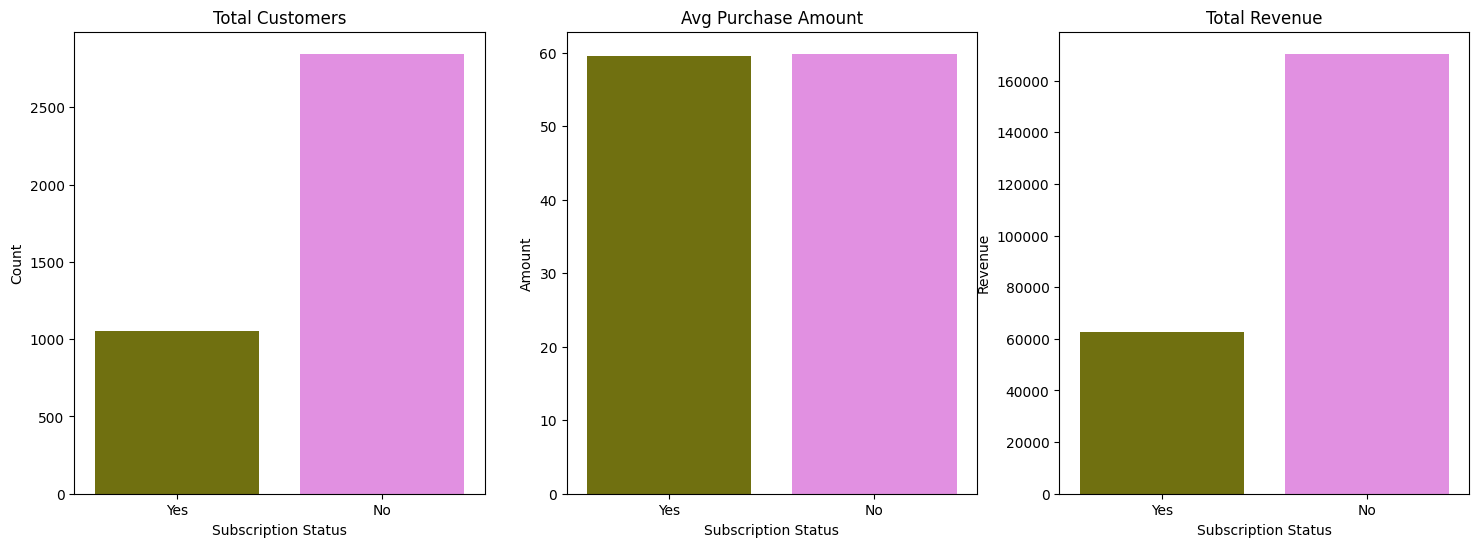

In [35]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

sns.barplot(
    x='subscription_status',
    y='total_customer',
    data = df_subscriber_revenue,
    hue='subscription_status',
    palette=['olive','violet'],
    ax=axes[0]
)
axes[0].set_title("Total Customers")
axes[0].set_xlabel('Subscription Status')
axes[0].set_ylabel("Count")

sns.barplot(
    x='subscription_status',
    y='avg_purchase_amt',
    data = df_subscriber_revenue,
    hue='subscription_status',
    palette=['olive','violet'],
    ax=axes[1]
)
axes[1].set_xlabel("Subscription Status")
axes[1].set_title('Avg Purchase Amount')
axes[1].set_ylabel("Amount")

sns.barplot(
    x='subscription_status',
    y='total_revenue',
    data = df_subscriber_revenue,
    hue='subscription_status',
    palette=['olive','violet'],
    ax=axes[2]
)
axes[2].set_title("Total Revenue")
axes[2].set_xlabel('Subscription Status')
axes[2].set_ylabel("Revenue")
plt.show()


In [39]:
### Q6. Which 5 products have the highest percentage of purchases with discounts applied?
df_product_percentage = pd.read_sql("""
SELECT item_purchased,
COUNT(*) AS total_purchase,
SUM(CASE WHEN discount_applied = 'Yes' THEN 1 ELSE 0 END) AS discounted_purchase,
ROUND(SUM(CASE WHEN discount_applied = 'Yes' THEN 1 ELSE 0 END) * 100 / COUNT(*),2) AS discount_percentage
FROM customer
GROUP BY item_purchased
ORDER BY discount_percentage DESC
LIMIT 5
""",engine)
print(df_product_percentage)


  item_purchased  total_purchase  discounted_purchase  discount_percentage
0            Hat             154                   77                 50.0
1       Sneakers             145                   72                 49.0
2           Coat             161                   79                 49.0
3        Sweater             164                   79                 48.0
4          Pants             171                   81                 47.0


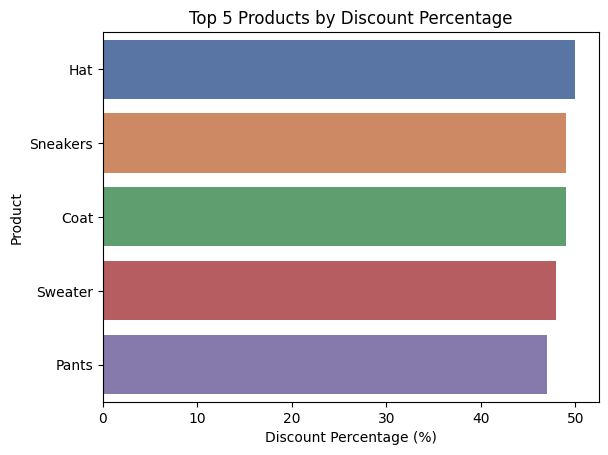

In [48]:
sns.barplot(x = 'discount_percentage',y='item_purchased',data = df_product_percentage,hue='item_purchased',palette='deep')
plt.title('Top 5 Products by Discount Percentage')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Product')
plt.show()

In [61]:
### Q7. Segment customers into New , Returning and Loyal based on their total number of previous purchase , and show the count of each segment
df_previous_purchase = pd.read_sql("""
SELECT 
CASE 
WHEN previous_purchases = 1 THEN 'New'
WHEN previous_purchases BETWEEN 2 AND 10 THEN 'Returning'
ELSE 'Loyal'
END AS customer_segment,
COUNT(*) AS customer_count
FROM customer
GROUP BY customer_segment

""",engine)
print(df_previous_purchase)

  customer_segment  customer_count
0            Loyal            3116
1              New              83
2        Returning             701


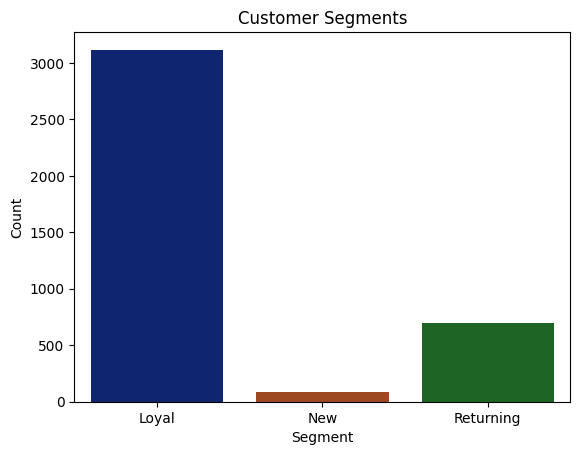

In [68]:
sns.barplot(data = df_previous_purchase,x = 'customer_segment',y='customer_count',
             hue='customer_segment', palette='dark')
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')

plt.show()

In [82]:
### Q8. What are the top 3 most purchased products within each category?
df_top3_category = pd.read_sql("""
WITH ranked AS(
SELECT category,item_purchased,COUNT(*) AS purchased_count,
DENSE_RANK() OVER(
PARTITION BY category
ORDER BY COUNT(*) DESC
) AS rnk
FROM customer
GROUP BY category,item_purchased
)

SELECT 
category,
item_purchased,
purchased_count,
rnk
FROM ranked
WHERE rnk <=3
ORDER BY category,rnk 


""",engine)
print(df_top3_category)



       category item_purchased  purchased_count  rnk
0   Accessories        Jewelry              171    1
1   Accessories     Sunglasses              161    2
2   Accessories           Belt              161    2
3   Accessories          Scarf              157    3
4      Clothing         Blouse              171    1
5      Clothing          Pants              171    1
6      Clothing          Shirt              169    2
7      Clothing          Dress              166    3
8      Footwear        Sandals              160    1
9      Footwear          Shoes              150    2
10     Footwear       Sneakers              145    3
11    Outerwear         Jacket              163    1
12    Outerwear           Coat              161    2


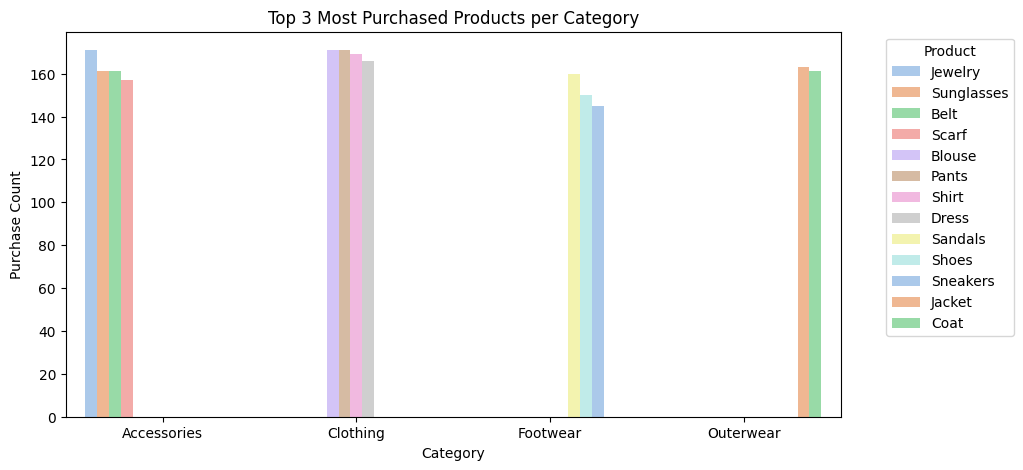

In [87]:
plt.figure(figsize=(10,5))
sns.barplot(data = df_top3_category,x='category',y='purchased_count',hue='item_purchased'
            ,palette='pastel')
plt.title('Top 3 Most Purchased Products per Category')
plt.xlabel('Category')
plt.ylabel('Purchase Count')
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [89]:
### Q9. Are customers who are repeat buyers (more than 5 previous purchases) also likely to subscribe?
df_repeat_buyers_subscribers = pd.read_sql("""
SELECT subscription_status,
COUNT(customer_id) as repeat_buyers
FROM customer
WHERE previous_purchases > 5
GROUP BY subscription_status

""",engine)
print(df_repeat_buyers_subscribers)

  subscription_status  repeat_buyers
0                  No           2518
1                 Yes            958


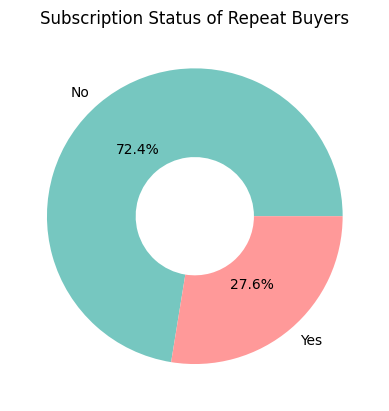

In [105]:
plt.pie(df_repeat_buyers_subscribers['repeat_buyers'],
       labels=df_repeat_buyers_subscribers['subscription_status']
       ,autopct='%1.1f%%',
       colors=['#76c7c0', '#ff9999'],
       wedgeprops=dict(width=0.6))
plt.title('Subscription Status of Repeat Buyers')
        
plt.show()


In [109]:
### Q10. What is the revenue contribution of each age group
df_revenue_age_group = pd.read_sql("""
SELECT age_group , SUM(purchase_amount) AS total_revenue
FROM customer
GROUP BY age_group
ORDER BY total_revenue DESC

""",engine)
print(df_revenue_age_group)

     age_group  total_revenue
0  Young Adult        62143.0
1  Middle-aged        59197.0
2        Adult        55978.0
3       Senior        55763.0


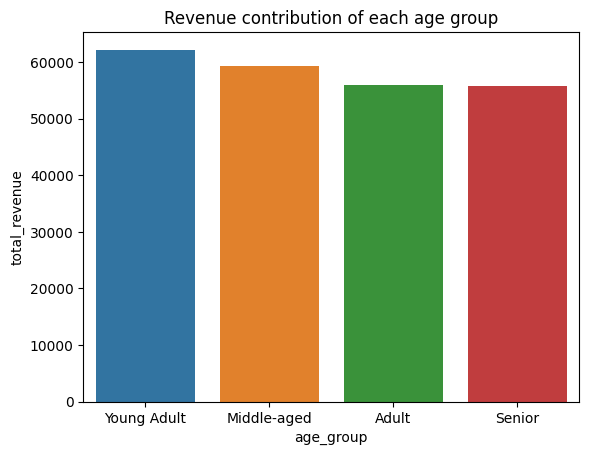

In [113]:
sns.barplot(x = 'age_group',y='total_revenue',data = df_revenue_age_group,hue='age_group')
plt.title("Revenue contribution of each age group")
plt.show()